### Importing the necessary libraries

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Buliding the LogisticTorch model

In [10]:
class LogisticTorch:
    def __init__(self, lr = 0.01, epochs = 1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []          
        
    def sigmoid(self,x):
        x = torch.clamp(x,-250,250)
        return 1/(1+torch.exp(-x))
    
    def fit(self,x,y):
        x = torch.FloatTensor(x)
        y = torch.FloatTensor(y).reshape(-1,1)
        
        n_features = x.shape[1]
        self.weights = torch.randn(n_features,1,requires_grad=True)
        self.bias = torch.zeros(1,1,requires_grad=True)
        
        for epoch in range(self.epochs):
            z = torch.mm(x, self.weights) + self.bias
            predictions = self.sigmoid(z)
            
            loss = -torch.mean(y * torch.log(predictions + 1e-8) + (1-y) * torch.log(1-predictions + 1e-8))
            self.losses.append(loss.item())
            loss.backward()
            
            with torch.no_grad():
                self.weights -= self.lr * self.weights.grad
                self.bias -= self.lr * self.bias.grad
                self.weights.grad.zero_()
                self.bias.grad.zero_()
                
    def predict_proba(self,x):
        x = torch.FloatTensor(x)
        with torch.no_grad():
            z = torch.mm(x, self.weights) + self.bias
            probabilities = self.sigmoid(z)
        return probabilities.numpy()
            
    def predict(self,x):
        probabilities = self.predict_proba(x)
        return (probabilities >= 0.5).astype(int).flatten()

### Visualising the dataset

In [11]:
x, y = make_moons(n_samples=200, noise=0.2, random_state=42)
print(x[:10],"\n")
print(y,"\n")

[[-1.10689665e+00  4.22928095e-02]
 [ 9.56799641e-01  4.56750492e-01]
 [ 7.33516277e-01  5.84617437e-01]
 [ 1.11140659e+00 -3.09213987e-01]
 [ 2.09081764e-01  6.56679495e-04]
 [ 3.92205613e-01  3.20238629e-01]
 [-7.56185073e-01  8.29954942e-01]
 [ 1.50692319e+00 -1.11129319e-01]
 [ 2.04279588e+00 -3.79762883e-02]
 [ 1.44143707e-01  9.16713583e-01]] 

[0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1
 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1
 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1
 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 0 0 1 1 1
 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1] 



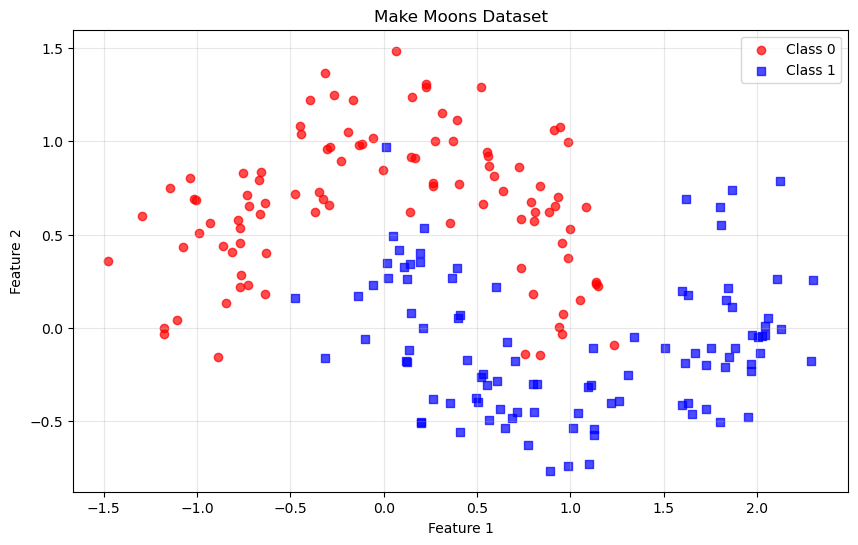

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(x[y==0, 0], x[y==0, 1], c='red', marker='o', label='Class 0', alpha=0.7)
plt.scatter(x[y==1, 0], x[y==1, 1], c='blue', marker='s', label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2') 
plt.title('Make Moons Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Training, plotting loss curve and calculating the accuracy

In [13]:
print("Training LogisticTorch model")
model_torch = LogisticTorch(lr=0.1, epochs=1000)
model_torch.fit(x, y)

Training LogisticTorch model


In [14]:
print("Training sklearn LogisticRegression model")
model_sklearn = LogisticRegression(random_state=42, max_iter=1000)
model_sklearn.fit(x, y)

Training sklearn LogisticRegression model


LogisticRegression(max_iter=1000, random_state=42)

 Make predictions with both models and calculating accuracies

In [15]:
y_pred_torch = model_torch.predict(x)
y_pred_sklearn = model_sklearn.predict(x)

accuracy_torch = accuracy_score(y, y_pred_torch)
accuracy_sklearn = accuracy_score(y, y_pred_sklearn)



print("MODEL PERFORMANCE COMPARISON")
print("-------------------------------------\n")
print(f"LogisticTorch Accuracy:     {accuracy_torch:.4f}")
print(f"Sklearn LogisticRegression: {accuracy_sklearn:.4f}")


MODEL PERFORMANCE COMPARISON
-------------------------------------

LogisticTorch Accuracy:     0.8550
Sklearn LogisticRegression: 0.8500


 Plot training loss curve for LogisticTorch

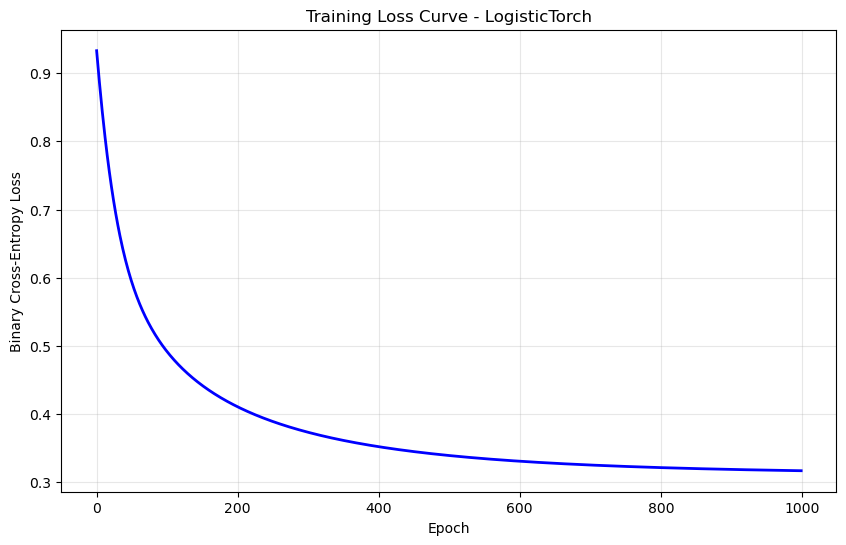

Final training loss: 0.316948


In [16]:
plt.figure(figsize=(10, 6))
plt.plot(model_torch.losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve - LogisticTorch')
plt.grid(True, alpha=0.3)
plt.show()


print(f"Final training loss: {model_torch.losses[-1]:.6f}")

Decsion Boundaries for both models

Decision Boundary Visualization
----------------------------------------


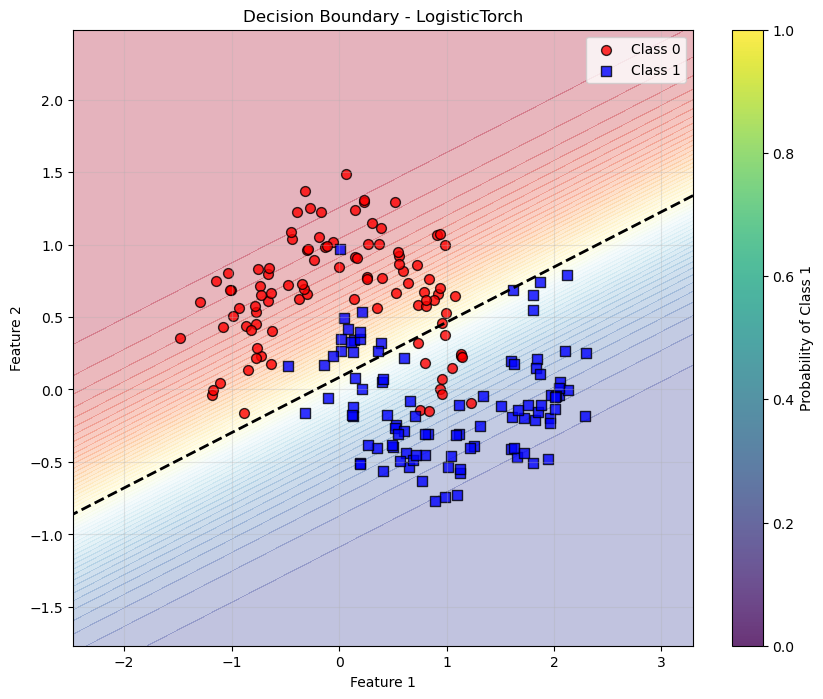

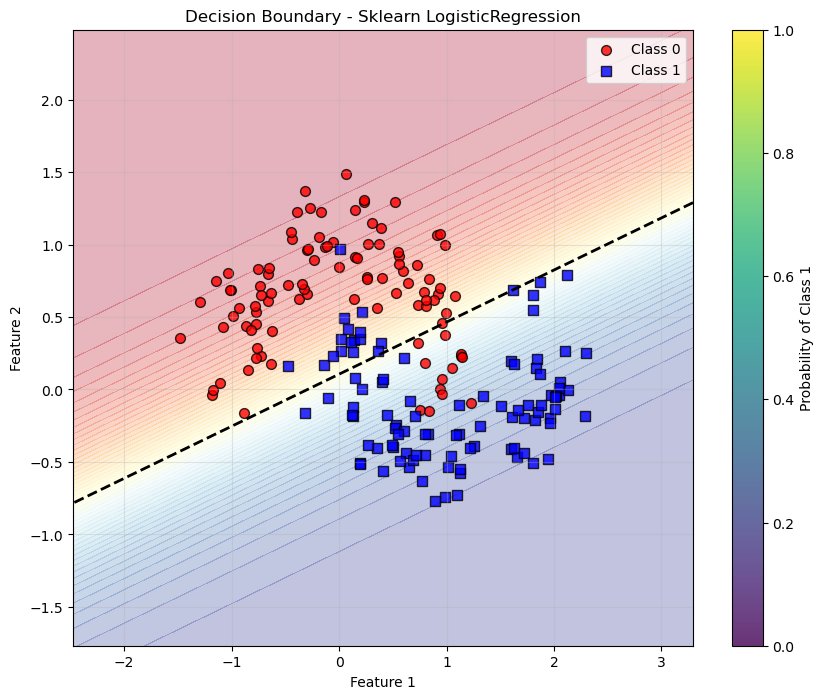

In [17]:
def plot_decision_boundary(X, y, model, model_name, is_sklearn=False):
    
    plt.figure(figsize=(10, 8))
    
    h = 0.01  #
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    
    if is_sklearn:
        Z = model.predict_proba(mesh_points)[:, 1]
        
    else:
        Z = model.predict_proba(mesh_points).flatten()
    
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
    
    plt.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap='RdYlBu')
    
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', s=50, label='Class 0', edgecolors='black', alpha=0.8)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='s', s=50, label='Class 1', edgecolors='black', alpha=0.8)
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Decision Boundary - {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Probability of Class 1')
    plt.show()

print("Decision Boundary Visualization")
print("-" * 40)

plot_decision_boundary(x, y, model_torch, "LogisticTorch", is_sklearn=False)

plot_decision_boundary(x, y, model_sklearn, "Sklearn LogisticRegression", is_sklearn=True)

Final Comparisions

In [18]:
print("------------------------------------------")
print("          FINAL RESULTS SUMMARY")
print("------------------------------------------\n")

print("------------------------------------------")
print(f"LogisticTorch (Custom):")
print(f"  - Learning Rate: {model_torch.lr}")
print(f"  - Epochs: {model_torch.epochs}")
print(f"  - Final Loss: {model_torch.losses[-1]:.6f}")
print(f"  - Accuracy: {accuracy_torch:.4f}")
print("------------------------------------------")
print(f"Sklearn LogisticRegression:")
print(f"  - Solver: Default (lbfgs)")   
print(f"  - Max Iterations: 1000")
print(f"  - Accuracy: {accuracy_sklearn:.4f}")
print("------------------------------------------")
print(f"Performance Difference: {abs(accuracy_sklearn - accuracy_torch):.4f}")


------------------------------------------
          FINAL RESULTS SUMMARY
------------------------------------------

------------------------------------------
LogisticTorch (Custom):
  - Learning Rate: 0.1
  - Epochs: 1000
  - Final Loss: 0.316948
  - Accuracy: 0.8550
------------------------------------------
Sklearn LogisticRegression:
  - Solver: Default (lbfgs)
  - Max Iterations: 1000
  - Accuracy: 0.8500
------------------------------------------
Performance Difference: 0.0050
